In [24]:
import numpy as np
import pandas as pd
import joblib
from scipy.optimize import minimize
from sklearn.linear_model import Ridge
import warnings
warnings.filterwarnings('ignore')

class SimpleMarketingModel:
    def __init__(self, model, feature_names):
        self.model = model
        self.coefficients = dict(zip(feature_names, model.coef_))
        self.intercept = model.intercept_

# Load model
model = joblib.load('marketing_model_simple.pkl')

# Load data
df = pd.read_csv('marketing_dataset_sample.csv')

print(" Model and data loaded")
print("\n Model coefficients:")
for col, coef in model.coefficients.items():
    print(f"   {col}: {coef:.6f}")

 Model and data loaded

 Model coefficients:
   FB_Effect: 61.388748
   GG_Effect: 91.968692
   Promo: 40.047848
   Seasonality: 68.147844


In [25]:
class BudgetOptimizer:
    
    def __init__(self, model, promo_value=0, season_value=1):
        self.model = model
        self.promo = promo_value
        self.season = season_value
        
        self.coef_fb = model.coefficients.get('FB_Effect', 0)
        self.coef_gg = model.coefficients.get('GG_Effect', 0)
        self.coef_promo = model.coefficients.get('Promo', 0)
        self.coef_season = model.coefficients.get('Seasonality', 0)
        self.intercept = model.model.intercept_
        
        print(f" Coefficients loaded:")
        print(f"   FB_Effect: {self.coef_fb:.4f}")
        print(f"   GG_Effect: {self.coef_gg:.4f}")
        print(f"   Promo: {self.coef_promo:.2f}")
        print(f"   Season: {self.coef_season:.2f}")
        print(f"   Intercept: {self.intercept:.2f}")
    
    def effect_from_spend(self, spend, channel='FB'):
        
        if channel == 'FB':
            ec50 = 5000  
            slope = 2
        else: 
            ec50 = 5000
            slope = 2
        
        effect = spend**slope / (ec50**slope + spend**slope)
        return effect
    
    def sales_function(self, spends):
        
        fb_spend, gg_spend = spends
        
        fb_effect = self.effect_from_spend(fb_spend, 'FB')
        gg_effect = self.effect_from_spend(gg_spend, 'GG')
        
        sales = (self.coef_fb * fb_effect + 
                 self.coef_gg * gg_effect + 
                 self.coef_promo * self.promo +
                 self.coef_season * self.season +
                 self.intercept)
        
        return sales
    
    def objective(self, spends):
        return -self.sales_function(spends)
    
    def optimize(self, budget_total, min_spend=0, max_spend=None):
        n_channels = 2
        initial_spends = [budget_total / 2, budget_total / 2]
        
        constraints = [{'type': 'eq', 'fun': lambda x: np.sum(x) - budget_total}]
        
        if max_spend is None:
            max_spend = budget_total
        
        if isinstance(min_spend, (int, float)):
            min_spend = [min_spend, min_spend]
        if isinstance(max_spend, (int, float)):
            max_spend = [max_spend, max_spend]
        
        bounds = [(min_spend[i], max_spend[i]) for i in range(n_channels)]
        
        result = minimize(self.objective, initial_spends, 
                         method='SLSQP', 
                         bounds=bounds, 
                         constraints=constraints)
        
        if result.success:
            return result.x, -result.fun
        else:
            print(f"Warning: {result.message}")
            return initial_spends, self.sales_function(initial_spends)

print(" BudgetOptimizer class defined with saturation transformation")

 BudgetOptimizer class defined with saturation transformation


In [26]:
optimizer = BudgetOptimizer(model, promo_value=0, season_value=1)

budget = 10000
optimal_spends, optimal_sales = optimizer.optimize(budget, min_spend=500, max_spend=9000)

print("\n" + "="*50)
print("OPTIMIZATION RESULTS - Budget: 10,000")
print("="*50)
print(f" Optimal FB Spend: {optimal_spends[0]:.0f}")
print(f" Optimal GG Spend: {optimal_spends[1]:.0f}")
print(f" Expected Sales: {optimal_sales:.0f}")

fb_effect = optimizer.effect_from_spend(optimal_spends[0], 'FB')
gg_effect = optimizer.effect_from_spend(optimal_spends[1], 'GG')
print(f"\n Corresponding Effect values:")
print(f"   FB_Effect: {fb_effect:.4f}")
print(f"   GG_Effect: {gg_effect:.4f}")

 Coefficients loaded:
   FB_Effect: 61.3887
   GG_Effect: 91.9687
   Promo: 40.05
   Season: 68.15
   Intercept: 215.16

OPTIMIZATION RESULTS - Budget: 10,000
 Optimal FB Spend: 3959
 Optimal GG Spend: 6041
 Expected Sales: 362

 Corresponding Effect values:
   FB_Effect: 0.3854
   GG_Effect: 0.5934


In [31]:
# Tạo optimizer với class mới
optimizer = BudgetOptimizer(model, promo_value=0, season_value=1)

budgets = [5000, 10000, 15000, 20000, 30000]
results = []

for budget in budgets:
    try:
        optimal, sales = optimizer.optimize(budget, min_spend=500, max_spend=budget*0.9)
        
        # Tính ROI (sales trên 1000đ chi tiêu)
        roi = sales / budget * 1000
        
        results.append({
            'Budget': budget,
            'FB_Spend': optimal[0],
            'GG_Spend': optimal[1],
            'Expected_Sales': sales,
            'ROI': roi
        })
        print(f" Budget {budget}: FB={optimal[0]:.0f}, GG={optimal[1]:.0f}, Sales={sales:.0f}")
    except Exception as e:
        print(f" Budget {budget} failed: {e}")
        results.append({'Budget': budget, 'FB_Spend': 'error', 'GG_Spend': 'error', 
                       'Expected_Sales': 'error', 'ROI': 'error'})

df_results = pd.DataFrame(results)
print("\n" + "="*50)
print("OPTIMIZATION ACROSS BUDGETS")
print("="*50)
print(df_results.round(0) if 'error' not in df_results['Expected_Sales'].values else df_results)

 Coefficients loaded:
   FB_Effect: 61.3887
   GG_Effect: 91.9687
   Promo: 40.05
   Season: 68.15
   Intercept: 215.16
 Budget 5000: FB=500, GG=4500, Sales=325
 Budget 10000: FB=3959, GG=6041, Sales=362
 Budget 15000: FB=6640, GG=8360, Sales=390
 Budget 20000: FB=10000, GG=10000, Sales=406
 Budget 30000: FB=15000, GG=15000, Sales=421

OPTIMIZATION ACROSS BUDGETS
   Budget  FB_Spend  GG_Spend  Expected_Sales   ROI
0    5000     500.0    4500.0           325.0  65.0
1   10000    3959.0    6041.0           362.0  36.0
2   15000    6640.0    8360.0           390.0  26.0
3   20000   10000.0   10000.0           406.0  20.0
4   30000   15000.0   15000.0           421.0  14.0


In [32]:
budget = 10000

# No promo
opt_no_promo = BudgetOptimizer(model, promo_value=0, season_value=1)
fb_no, gg_no = opt_no_promo.optimize(budget, min_spend=500, max_spend=8000)[0]
sales_no = opt_no_promo.optimize(budget, min_spend=500, max_spend=8000)[1]

# In promo
opt_with_promo = BudgetOptimizer(model, promo_value=1, season_value=1)
fb_with, gg_with = opt_with_promo.optimize(budget, min_spend=500, max_spend=8000)[0]
sales_with = opt_with_promo.optimize(budget, min_spend=500, max_spend=8000)[1]

print("="*50)
print("PROMO COMPARISON (Budget: 10,000)")
print("="*50)
print(f"Without Promo: FB={fb_no:.0f}, GG={gg_no:.0f} → Sales={sales_no:.0f}")
print(f"With Promo:    FB={fb_with:.0f}, GG={gg_with:.0f} → Sales={sales_with:.0f}")
print(f"\n Lift from Promo: +{sales_with - sales_no:.0f} sales ({(sales_with/sales_no - 1)*100:.1f}%)")

 Coefficients loaded:
   FB_Effect: 61.3887
   GG_Effect: 91.9687
   Promo: 40.05
   Season: 68.15
   Intercept: 215.16
 Coefficients loaded:
   FB_Effect: 61.3887
   GG_Effect: 91.9687
   Promo: 40.05
   Season: 68.15
   Intercept: 215.16
PROMO COMPARISON (Budget: 10,000)
Without Promo: FB=3959, GG=6041 → Sales=362
With Promo:    FB=3960, GG=6040 → Sales=402

 Lift from Promo: +40 sales (11.1%)


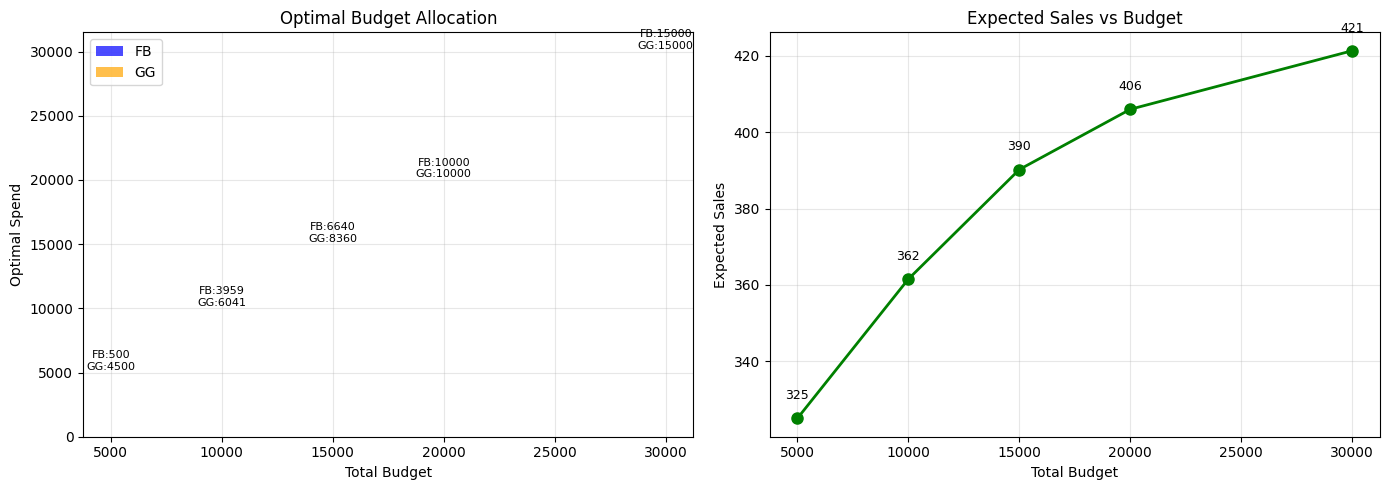


 OPTIMIZATION SUMMARY
    Budget |       FB |       GG |    Sales |      ROI
------------------------------------------------------------
      5000 |      500 |     4500 |      325 |     65.0
     10000 |     3959 |     6041 |      362 |     36.2
     15000 |     6640 |     8360 |      390 |     26.0
     20000 |    10000 |    10000 |      406 |     20.3
     30000 |    15000 |    15000 |      421 |     14.0


In [36]:
import matplotlib.pyplot as plt

budgets = df_results['Budget'].values
fb_spend = df_results['FB_Spend'].values
gg_spend = df_results['GG_Spend'].values
sales = df_results['Expected_Sales'].values

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(budgets, fb_spend, label='FB', alpha=0.7, color='blue')
axes[0].bar(budgets, gg_spend, bottom=fb_spend, label='GG', alpha=0.7, color='orange')
axes[0].set_xlabel('Total Budget')
axes[0].set_ylabel('Optimal Spend')
axes[0].set_title('Optimal Budget Allocation')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

for i, (fb, gg) in enumerate(zip(fb_spend, gg_spend)):
    axes[0].text(budgets[i], fb + gg + 200, f'FB:{fb:.0f}\nGG:{gg:.0f}', 
                 ha='center', fontsize=8)

axes[1].plot(budgets, sales, 'o-', linewidth=2, markersize=8, color='green')
axes[1].set_xlabel('Total Budget')
axes[1].set_ylabel('Expected Sales')
axes[1].set_title('Expected Sales vs Budget')
axes[1].grid(True, alpha=0.3)

for i, s in enumerate(sales):
    axes[1].text(budgets[i], s + 5, f'{s:.0f}', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

# Dashboard
print("\n" + "="*60)
print(" OPTIMIZATION SUMMARY")
print("="*60)
print(f"{'Budget':>10} | {'FB':>8} | {'GG':>8} | {'Sales':>8} | {'ROI':>8}")
print("-"*60)
for i in range(len(budgets)):
    print(f"{budgets[i]:>10.0f} | {fb_spend[i]:>8.0f} | {gg_spend[i]:>8.0f} | {sales[i]:>8.0f} | {df_results['ROI'].values[i]:>8.1f}")

In [37]:

df_results.to_csv('optimization_results.csv', index=False)
print(" Saved to 'optimization_results.csv'")

print("\n" + "="*50)
print("MODULE 3 - COMPLETED")
print("="*50)
print(f" Optimal allocation for budget {budget}:")
print(f"   FB: {optimal_spends[0]:.0f}")
print(f"   GG: {optimal_spends[1]:.0f}")
print(f"   Expected Sales: {optimal_sales:.0f}")

 Saved to 'optimization_results.csv'

MODULE 3 - COMPLETED
 Optimal allocation for budget 10000:
   FB: 3959
   GG: 6041
   Expected Sales: 362
